In [2]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)




Mounted at /content/drive


In [3]:
cd "/content/drive/MyDrive/Proyecto_final_int_red/"

/content/drive/MyDrive/Proyecto_final_int_red


In [4]:
ls

eurusd_hour.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import math as m
import datetime
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA


In [6]:
# Cleaning data
df=pd.read_csv('eurusd_hour.csv')
df = df[['Date', 'Time', 'BO', 'BH', 'BL', 'BC', 'BCh', 'AO', 'AH', 'AL', 'AC', 'ACh']]
display(df)

#creating dateime as the index
df['DateTime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str), dayfirst=True)
df = df.drop(['Date', 'Time'], axis=1)
df = df.set_index('DateTime')

#predicting on the varaible MID_OPEN Price as that is the most useful
df['MO']=(df['BO']+df['AO'])/2    #buang BO and AO so mengelakkan looks like cheating. value deterministic.
df = df.drop(['BO', 'AO'], axis=1)#removing these values so information is not redunadant

# Optional: drop rows with missing values
df = df.dropna()

# Check dataframe
print(df.shape)
print(df.head())
print(df.index)
display(df)

/tmp/ipython-input-2132440018.py:2: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('eurusd_hour.csv')


,Date,Time,BO,BH,BL,BC,BCh,AO,AH,AL,AC,ACh
0,02/05/2005,0:00,1.28520,1.28520,1.28400,1.28440,-0.00080,1.28540,1.28540,1.28420,1.28460,-0.00080
1,02/05/2005,1:00,1.28440,1.28480,1.28390,1.28420,-0.00020,1.28460,1.28500,1.28410,1.28440,-0.00020
2,02/05/2005,2:00,1.28430,1.28540,1.28410,1.28510,0.00080,1.28450,1.28560,1.28430,1.28530,0.00080
3,02/05/2005,3:00,1.28510,1.28590,1.28500,1.28510,0.00000,1.28530,1.28610,1.28520,1.28530,0.00000
4,02/05/2005,4:00,1.28520,1.28590,1.28490,1.28550,0.00030,1.28540,1.28610,1.28510,1.28570,0.00030
...,...,...,...,...,...,...,...,...,...,...,...,...
93079,29/04/2020,18:00,1.08620,1.08851,1.08611,1.08713,0.00093,1.08660,1.08865,1.08640,1.08726,0.00066
93080,29/04/2020,19:00,1.08711,1.08823,1.08659,1.08748,0.00037,1.08725,1.08837,1.08675,1.08760,0.00035
93081,29/04/2020,20:00,1.08747,1.08788,1.08691,1.08708,-0.00039,1.08758,1.08810,1.08706,1.08808,0.00050
93082,29/04/2020,21:00,1.08708,1.08740,1.08699,1.08714,0.00006,1.08808,1.08814,1.08763,1.08766,-0.00042


(93084, 9)
                         BH      BL      BC     BCh      AH      AL      AC  \
DateTime                                                                      
2005-05-02 00:00:00  1.2852  1.2840  1.2844 -0.0008  1.2854  1.2842  1.2846   
2005-05-02 01:00:00  1.2848  1.2839  1.2842 -0.0002  1.2850  1.2841  1.2844   
2005-05-02 02:00:00  1.2854  1.2841  1.2851  0.0008  1.2856  1.2843  1.2853   
2005-05-02 03:00:00  1.2859  1.2850  1.2851  0.0000  1.2861  1.2852  1.2853   
2005-05-02 04:00:00  1.2859  1.2849  1.2855  0.0003  1.2861  1.2851  1.2857   

                        ACh      MO  
DateTime                             
2005-05-02 00:00:00 -0.0008  1.2853  
2005-05-02 01:00:00 -0.0002  1.2845  
2005-05-02 02:00:00  0.0008  1.2844  
2005-05-02 03:00:00  0.0000  1.2852  
2005-05-02 04:00:00  0.0003  1.2853  
DatetimeIndex(['2005-05-02 00:00:00', '2005-05-02 01:00:00',
               '2005-05-02 02:00:00', '2005-05-02 03:00:00',
               '2005-05-02 04:00:00', '2005-05-

,BH,BL,BC,BCh,AH,AL,AC,ACh,MO
DateTime,,,,,,,,,
2005-05-02 00:00:00,1.28520,1.28400,1.28440,-0.00080,1.28540,1.28420,1.28460,-0.00080,1.285300
2005-05-02 01:00:00,1.28480,1.28390,1.28420,-0.00020,1.28500,1.28410,1.28440,-0.00020,1.284500
2005-05-02 02:00:00,1.28540,1.28410,1.28510,0.00080,1.28560,1.28430,1.28530,0.00080,1.284400
2005-05-02 03:00:00,1.28590,1.28500,1.28510,0.00000,1.28610,1.28520,1.28530,0.00000,1.285200
2005-05-02 04:00:00,1.28590,1.28490,1.28550,0.00030,1.28610,1.28510,1.28570,0.00030,1.285300
...,...,...,...,...,...,...,...,...,...
2020-04-29 18:00:00,1.08851,1.08611,1.08713,0.00093,1.08865,1.08640,1.08726,0.00066,1.086400
2020-04-29 19:00:00,1.08823,1.08659,1.08748,0.00037,1.08837,1.08675,1.08760,0.00035,1.087180
2020-04-29 20:00:00,1.08788,1.08691,1.08708,-0.00039,1.08810,1.08706,1.08808,0.00050,1.087525


In [7]:
print("BO : Opening bid Price")
print("BH : Highest Bid Price (en una hora)")
print("BL :Lowest Bid Price (en una hora)")
print("BC : Closing Bid Price")
print("BCh : Change in Bid/Open Price")
print("AO : Opening ask price")
print("AH : Highest Ask Price (en una hora)")
print("AL : Lowest Ask Price (en una hora)")
print("AC : Closing Ask Price")
print("ACh : Change in Ask/Open Price")

BO : Opening bid Price
BH : Highest Bid Price (en una hora)
BL :Lowest Bid Price (en una hora)
BC : Closing Bid Price
BCh : Change in Bid/Open Price
AO : Opening ask price
AH : Highest Ask Price (en una hora)
AL : Lowest Ask Price (en una hora)
AC : Closing Ask Price
ACh : Change in Ask/Open Price


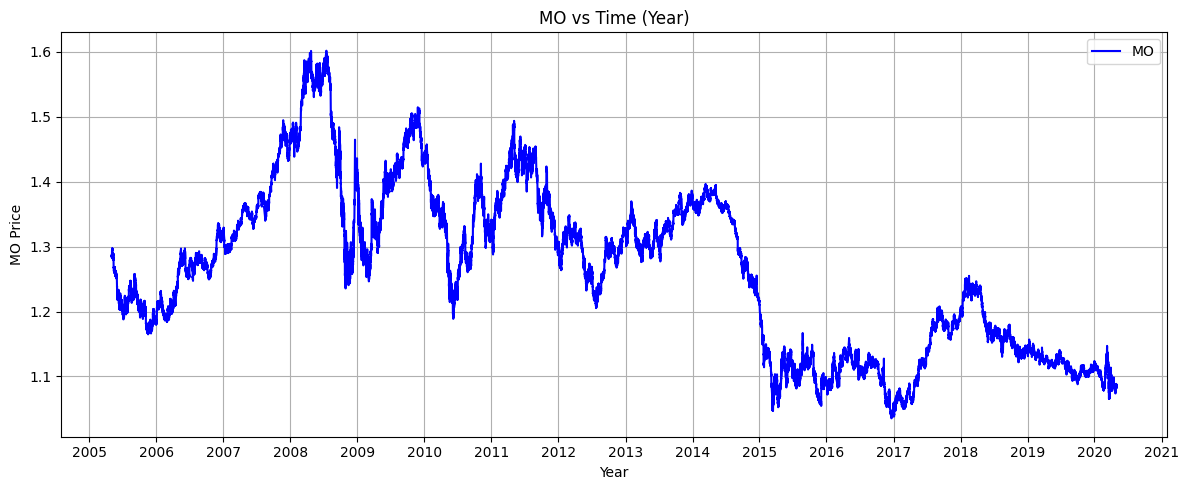

In [8]:
# Plot MO(the value i wanna predict)
plt.figure(figsize=(12,5))
plt.plot(df.index, df['MO'], color='blue', label='MO')

# Format x-axis to show only year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())  # one tick per year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # show only year

# Labels and title
plt.xlabel('Year')
plt.ylabel('MO Price')
plt.title('MO vs Time (Year)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
#Preparing the midprice shifted by n
def linear_reg(df,n):

 df_temp=df
 df_temp['MO_future'] = df_temp['MO'].shift(-n)
 df_temp = df_temp[:-n] #removing last n NaN values

 #defining variables and target variable.Our target variable is future values
 features = ['BH','BL','BC','BCh','AH','AL','AC','ACh']
 X = df_temp[features]
 y = df_temp['MO_future']

 #splitting the datsize into train,evaluatio and test modules

 X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=0.2, shuffle=False
 )
 #scaling the dataset


 scaler = StandardScaler()
 X_train = scaler.fit_transform(X_train)

 X_test  = scaler.transform(X_test)
 #testing if partitions make sense
 n_tr  = len(X_train)
 n_tst = len(X_test)


 model = LinearRegression()
 model.fit(X_train, y_train)

 #prediction
 y_pred = model.predict(X_test)

 #prediction on y_train
 y_pred_train=model.predict(X_train)

 #model evaluation
 mse = mean_squared_error(y_test, y_pred)
 rmse= m.sqrt(mse)
 mae=mean_absolute_error(y_test, y_pred)
 r2 = r2_score(y_test, y_pred)
 r2_score_train = r2_score(y_train,y_pred_train)

 comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred , 'Index':y_test.index})

 return r2, model.coef_, mse ,rmse ,mae ,comparison ,r2_score_train

nIf i do not shift my values to the back then I am not acutally making a time prediction.In this particular model the value of the futue will depend on ONE particular mid _price value.

In [10]:
n=24*7*4 #lets say we wanna predict 1 month
r2,coef,mse,rmse,mae,comparison,r2train=linear_reg(df,n)

#Model evaluation
print("The rmse of test is  : ",rmse)
print("The mae of test is: ",mae)
print("The r2 score test is : ",r2)
print("The r2 score of train is : ",r2train)
print("The difference in absolute values is : ",abs(r2-r2train))
print("The coeficients are : ",coef)
print(comparison.head(10))
display(df)


The rmse of test is  :  0.023304340590639468
The mae of test is:  0.01818389279837463
The r2 score test is :  0.6786982981050736
The r2 score of train is :  0.8782597845227585
The difference in absolute values is :  0.1995614864176849
The coeficients are :  [ 0.88875795  0.67186916 -0.40519191  0.00457478 -1.00120927 -0.52897629
  0.49120118 -0.00429183]
     Actual  Predicted               Index
0  1.090385   1.086898 2017-03-24 02:00:00
1  1.089515   1.087755 2017-03-24 03:00:00
2  1.088675   1.087247 2017-03-24 04:00:00
3  1.088425   1.087618 2017-03-24 05:00:00
4  1.088905   1.087022 2017-03-24 06:00:00
5  1.088815   1.087622 2017-03-24 07:00:00
6  1.088680   1.088032 2017-03-24 08:00:00
7  1.089295   1.090554 2017-03-24 09:00:00
8  1.089180   1.090627 2017-03-24 10:00:00
9  1.089660   1.090958 2017-03-24 11:00:00


,BH,BL,BC,BCh,AH,AL,AC,ACh,MO,MO_future
DateTime,,,,,,,,,,
2005-05-02 00:00:00,1.28520,1.28400,1.28440,-0.00080,1.28540,1.28420,1.28460,-0.00080,1.285300,1.223935
2005-05-02 01:00:00,1.28480,1.28390,1.28420,-0.00020,1.28500,1.28410,1.28440,-0.00020,1.284500,1.224005
2005-05-02 02:00:00,1.28540,1.28410,1.28510,0.00080,1.28560,1.28430,1.28530,0.00080,1.284400,1.224555
2005-05-02 03:00:00,1.28590,1.28500,1.28510,0.00000,1.28610,1.28520,1.28530,0.00000,1.285200,1.223755
2005-05-02 04:00:00,1.28590,1.28490,1.28550,0.00030,1.28610,1.28510,1.28570,0.00030,1.285300,1.223855
...,...,...,...,...,...,...,...,...,...,...
2020-04-29 18:00:00,1.08851,1.08611,1.08713,0.00093,1.08865,1.08640,1.08726,0.00066,1.086400,NaN
2020-04-29 19:00:00,1.08823,1.08659,1.08748,0.00037,1.08837,1.08675,1.08760,0.00035,1.087180,NaN
2020-04-29 20:00:00,1.08788,1.08691,1.08708,-0.00039,1.08810,1.08706,1.08808,0.00050,1.087525,NaN


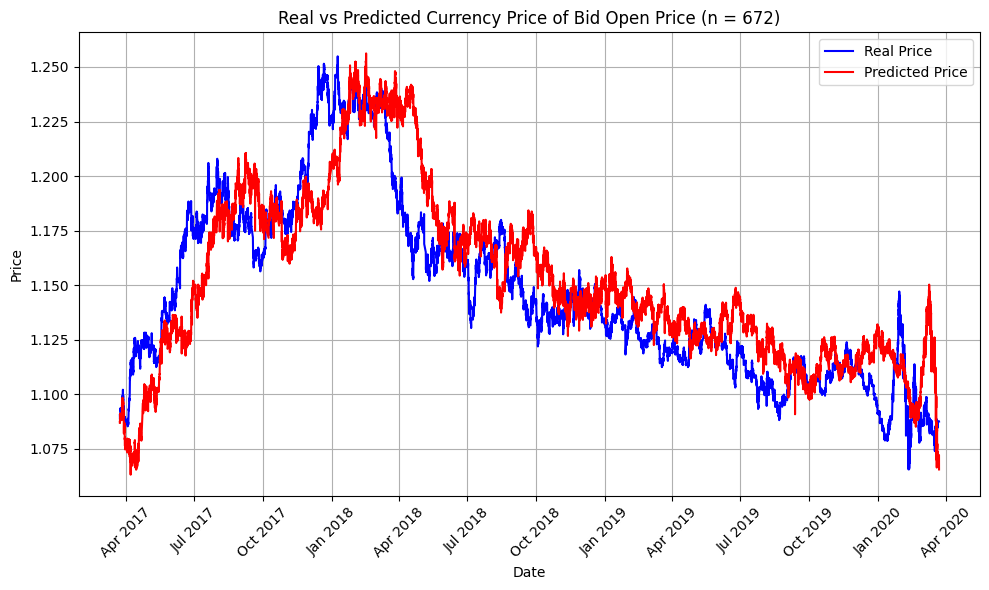

In [11]:
# Create figure
fig, ax = plt.subplots(figsize=(10,6))

# Plot Actual and Predicted
ax.plot(comparison['Index'], comparison['Actual'], label='Real Price', color='blue')
ax.plot(comparison['Index'], comparison['Predicted'], label='Predicted Price', color='red')

# Format x-axis to show Month and Year
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Rotate labels
plt.xticks(rotation=45)

# Labels, title, legend, grid
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.set_title(f'Real vs Predicted Currency Price of Bid Open Price (n = {n})')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

ARIMA-How well can i predict without additional prediction in 24 hours

In [12]:
#Data preparation
l = 24*7*2 #cutting the dataframe because my datset to big
n = 24

In [13]:
display(df)

,BH,BL,BC,BCh,AH,AL,AC,ACh,MO,MO_future
DateTime,,,,,,,,,,
2005-05-02 00:00:00,1.28520,1.28400,1.28440,-0.00080,1.28540,1.28420,1.28460,-0.00080,1.285300,1.223935
2005-05-02 01:00:00,1.28480,1.28390,1.28420,-0.00020,1.28500,1.28410,1.28440,-0.00020,1.284500,1.224005
2005-05-02 02:00:00,1.28540,1.28410,1.28510,0.00080,1.28560,1.28430,1.28530,0.00080,1.284400,1.224555
2005-05-02 03:00:00,1.28590,1.28500,1.28510,0.00000,1.28610,1.28520,1.28530,0.00000,1.285200,1.223755
2005-05-02 04:00:00,1.28590,1.28490,1.28550,0.00030,1.28610,1.28510,1.28570,0.00030,1.285300,1.223855
...,...,...,...,...,...,...,...,...,...,...
2020-04-29 18:00:00,1.08851,1.08611,1.08713,0.00093,1.08865,1.08640,1.08726,0.00066,1.086400,NaN
2020-04-29 19:00:00,1.08823,1.08659,1.08748,0.00037,1.08837,1.08675,1.08760,0.00035,1.087180,NaN
2020-04-29 20:00:00,1.08788,1.08691,1.08708,-0.00039,1.08810,1.08706,1.08808,0.00050,1.087525,NaN


In [14]:

df_red = df.iloc[-l:]
display(df_red)
Y_test = df_red['MO'].iloc[-n:] #the actual values i wanna predict.The last n
X_train = df_red['MO'].iloc[:-n]


,BH,BL,BC,BCh,AH,AL,AC,ACh,MO,MO_future
DateTime,,,,,,,,,,
2020-04-09 23:00:00,1.09321,1.09168,1.09193,-0.00057,1.09410,1.09239,1.09267,-0.00062,1.092895,NaN
2020-04-10 00:00:00,1.09246,1.09172,1.09207,0.00014,1.09287,1.09214,1.09237,-0.00022,1.092260,NaN
2020-04-10 01:00:00,1.09263,1.09186,1.09261,0.00050,1.09311,1.09223,1.09311,0.00074,1.092240,NaN
2020-04-10 02:00:00,1.09343,1.09239,1.09326,0.00069,1.09386,1.09281,1.09372,0.00064,1.092825,NaN
2020-04-10 03:00:00,1.09430,1.09297,1.09408,0.00093,1.09472,1.09355,1.09450,0.00083,1.093410,NaN
...,...,...,...,...,...,...,...,...,...,...
2020-04-29 18:00:00,1.08851,1.08611,1.08713,0.00093,1.08865,1.08640,1.08726,0.00066,1.086400,NaN
2020-04-29 19:00:00,1.08823,1.08659,1.08748,0.00037,1.08837,1.08675,1.08760,0.00035,1.087180,NaN
2020-04-29 20:00:00,1.08788,1.08691,1.08708,-0.00039,1.08810,1.08706,1.08808,0.00050,1.087525,NaN


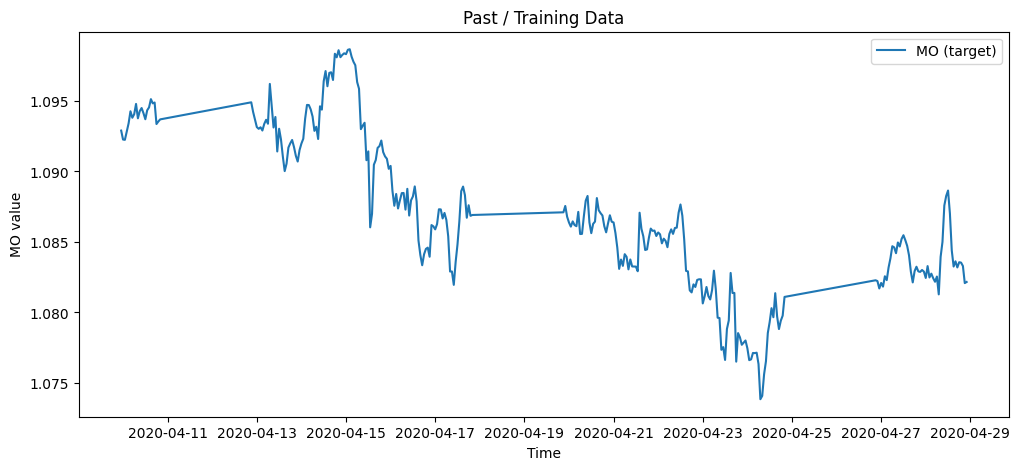

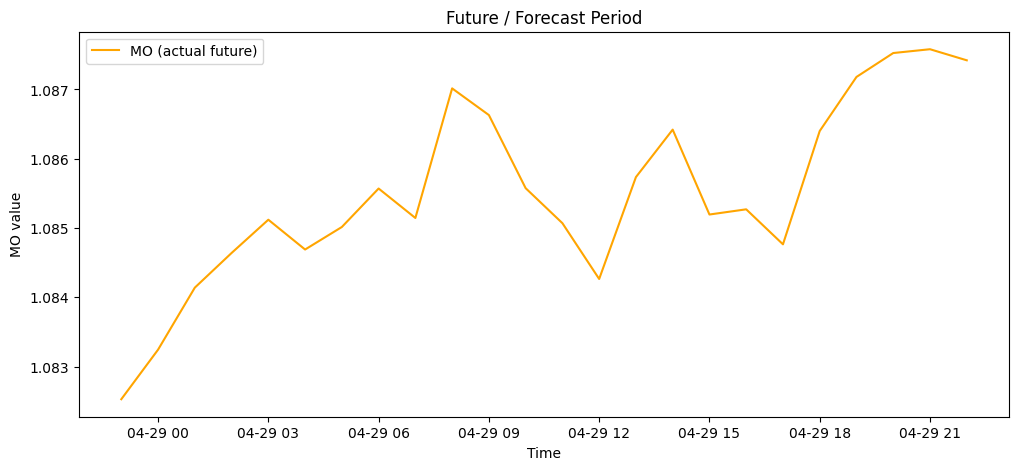

In [15]:
#visualize both trainn and test
plt.figure(figsize=(12,5))
plt.plot(X_train.index, X_train, label='MO (target)')
plt.title('Past / Training Data')
plt.xlabel('Time')
plt.ylabel('MO value')
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(Y_test.index, Y_test, label='MO (actual future)', color='orange')
plt.title('Future / Forecast Period')
plt.xlabel('Time')
plt.ylabel('MO value')
plt.legend()
plt.show()

In [16]:
#building model
p=1 #These values just works
q=1 #These values just works

model = ARIMA(endog=X_train,order=(p,0,q))
model_fit = model.fit()
Y_pred = model_fit.forecast(steps=n)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

In [17]:
Y_pred.index=Y_test.index
display(Y_pred)
display(Y_test)

,predicted_mean
DateTime,
2020-04-28 23:00:00,1.082254
2020-04-29 00:00:00,1.082345
2020-04-29 01:00:00,1.082435
2020-04-29 02:00:00,1.082522
2020-04-29 03:00:00,1.082609
2020-04-29 04:00:00,1.082693
2020-04-29 05:00:00,1.082776
2020-04-29 06:00:00,1.082857
2020-04-29 07:00:00,1.082937


,MO
DateTime,
2020-04-28 23:00:00,1.082530
2020-04-29 00:00:00,1.083245
2020-04-29 01:00:00,1.084140
2020-04-29 02:00:00,1.084640
2020-04-29 03:00:00,1.085120
2020-04-29 04:00:00,1.084690
2020-04-29 05:00:00,1.085015
2020-04-29 06:00:00,1.085570
2020-04-29 07:00:00,1.085145


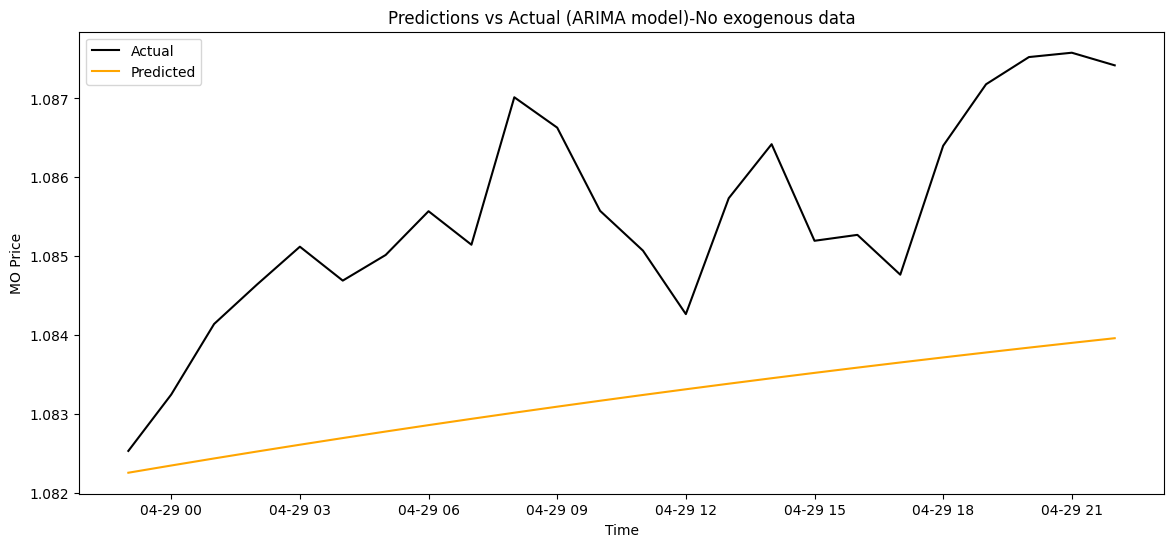

In [18]:

# Plot
plt.figure(figsize=(14,6))
plt.plot(Y_test.index, Y_test.values, label='Actual', color='black')
plt.plot(Y_pred.index, Y_pred, label=f'Predicted', color='orange')
plt.title('Predictions vs Actual (ARIMA model)-No exogenous data')
plt.xlabel('Time')
plt.ylabel('MO Price')
plt.legend()
plt.show()


I am using two week of data to 24 hours.Training beyond this does not improve the model.

ARIMAX.Using Exogenous features to add information.

In [42]:
#Data preparation
l = 24*2 #cutting the dataframe because my datset to big
n = 24

In [43]:

df_red2 = df.iloc[-l:]
display(df_red2)
Y_test = df_red2['MO'].iloc[-n:] #the actual values i wanna predict.The last n
X_train = df_red2['MO'].iloc[:-n]


,BH,BL,BC,BCh,AH,AL,AC,ACh,MO,MO_future
DateTime,,,,,,,,,,
2020-04-27 23:00:00,1.08293,1.08228,1.08239,-0.00042,1.08310,1.08243,1.08254,-0.00044,1.082895,NaN
2020-04-28 00:00:00,1.08353,1.08220,1.08323,0.00087,1.08372,1.08236,1.08337,0.00084,1.082445,NaN
2020-04-28 01:00:00,1.08338,1.08228,1.08242,-0.00078,1.08353,1.08244,1.08257,-0.00080,1.083285,NaN
2020-04-28 02:00:00,1.08275,1.08231,1.08269,0.00029,1.08290,1.08247,1.08283,0.00027,1.082480,NaN
2020-04-28 03:00:00,1.08268,1.08230,1.08237,-0.00031,1.08284,1.08244,1.08252,-0.00030,1.082750,NaN
2020-04-28 04:00:00,1.08236,1.08162,1.08211,-0.00025,1.08250,1.08177,1.08227,-0.00023,1.082430,NaN
2020-04-28 05:00:00,1.08268,1.08183,1.08245,0.00035,1.08283,1.08197,1.08260,0.00035,1.082175,NaN
2020-04-28 06:00:00,1.08249,1.08089,1.08120,-0.00127,1.08264,1.08104,1.08134,-0.00128,1.082545,NaN
2020-04-28 07:00:00,1.08402,1.08094,1.08386,0.00265,1.08417,1.08107,1.08399,0.00264,1.081280,NaN


In [44]:
#deciding which exogenous features to use
exog = df[['BH','BL','BC','BCh','AH','AL','AC','ACh']]
stds = exog.std()
print("Standard deviation of each feature:")
print(stds)
cv = exog.std() / exog.mean()
print("Coefficient of Variation :")
print(cv)
acf1 = exog.apply(lambda x: x.autocorr(lag=n))
print("Autocorrelation at lag n :")
print(acf1)

Standard deviation of each feature:
BH     0.127060
BL     0.126722
BC     0.126892
BCh    0.001544
AH     0.127053
AL     0.126715
AC     0.126891
ACh    0.001546
dtype: float64
Coefficient of Variation :
BH        0.100303
BL        0.100197
BC        0.100252
BCh   -1729.454867
AH        0.100285
AL        0.100178
AC        0.100238
ACh   -1530.495383
dtype: float64
Autocorrelation at lag n :
BH     0.998210
BL     0.998209
BC     0.998212
BCh    0.006318
AH     0.998209
AL     0.998210
AC     0.998213
ACh    0.007480
dtype: float64


In [45]:
#We will assume that I can get the values of BH and BL due to thier predictability.We can also assume economic statbility wich will cause these values to not fluctuate.
#defining Exogenous fwetures
exog = df_red2[['BC']]



exog_fut=exog.iloc[-n:]
exog_past=exog.iloc[:-n]


In [47]:
display(df_red2)
display(exog_past)
display(X_train)

,BH,BL,BC,BCh,AH,AL,AC,ACh,MO,MO_future
DateTime,,,,,,,,,,
2020-04-27 23:00:00,1.08293,1.08228,1.08239,-0.00042,1.08310,1.08243,1.08254,-0.00044,1.082895,NaN
2020-04-28 00:00:00,1.08353,1.08220,1.08323,0.00087,1.08372,1.08236,1.08337,0.00084,1.082445,NaN
2020-04-28 01:00:00,1.08338,1.08228,1.08242,-0.00078,1.08353,1.08244,1.08257,-0.00080,1.083285,NaN
2020-04-28 02:00:00,1.08275,1.08231,1.08269,0.00029,1.08290,1.08247,1.08283,0.00027,1.082480,NaN
2020-04-28 03:00:00,1.08268,1.08230,1.08237,-0.00031,1.08284,1.08244,1.08252,-0.00030,1.082750,NaN
2020-04-28 04:00:00,1.08236,1.08162,1.08211,-0.00025,1.08250,1.08177,1.08227,-0.00023,1.082430,NaN
2020-04-28 05:00:00,1.08268,1.08183,1.08245,0.00035,1.08283,1.08197,1.08260,0.00035,1.082175,NaN
2020-04-28 06:00:00,1.08249,1.08089,1.08120,-0.00127,1.08264,1.08104,1.08134,-0.00128,1.082545,NaN
2020-04-28 07:00:00,1.08402,1.08094,1.08386,0.00265,1.08417,1.08107,1.08399,0.00264,1.081280,NaN


,BC
DateTime,
2020-04-27 23:00:00,1.08239
2020-04-28 00:00:00,1.08323
2020-04-28 01:00:00,1.08242
2020-04-28 02:00:00,1.08269
2020-04-28 03:00:00,1.08237
2020-04-28 04:00:00,1.08211
2020-04-28 05:00:00,1.08245
2020-04-28 06:00:00,1.08120
2020-04-28 07:00:00,1.08386


,MO
DateTime,
2020-04-27 23:00:00,1.082895
2020-04-28 00:00:00,1.082445
2020-04-28 01:00:00,1.083285
2020-04-28 02:00:00,1.082480
2020-04-28 03:00:00,1.082750
2020-04-28 04:00:00,1.082430
2020-04-28 05:00:00,1.082175
2020-04-28 06:00:00,1.082545
2020-04-28 07:00:00,1.081280


In [49]:
#Actual ARIMAX model
p=1
q=1
model = ARIMA(endog=X_train, exog=exog_past, order=(p,0,q))
model_fit = model.fit()
Y_pred = model_fit.forecast(steps=n, exog=exog_fut)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [25]:

Y_pred.index=Y_test.index
display(Y_pred)
display(Y_test)

,predicted_mean
DateTime,
2020-04-28 23:00:00,1.083156
2020-04-29 00:00:00,1.084052
2020-04-29 01:00:00,1.084487
2020-04-29 02:00:00,1.084892
2020-04-29 03:00:00,1.084541
2020-04-29 04:00:00,1.084805
2020-04-29 05:00:00,1.085257
2020-04-29 06:00:00,1.084903
2020-04-29 07:00:00,1.086472


,MO
DateTime,
2020-04-28 23:00:00,1.082530
2020-04-29 00:00:00,1.083245
2020-04-29 01:00:00,1.084140
2020-04-29 02:00:00,1.084640
2020-04-29 03:00:00,1.085120
2020-04-29 04:00:00,1.084690
2020-04-29 05:00:00,1.085015
2020-04-29 06:00:00,1.085570
2020-04-29 07:00:00,1.085145


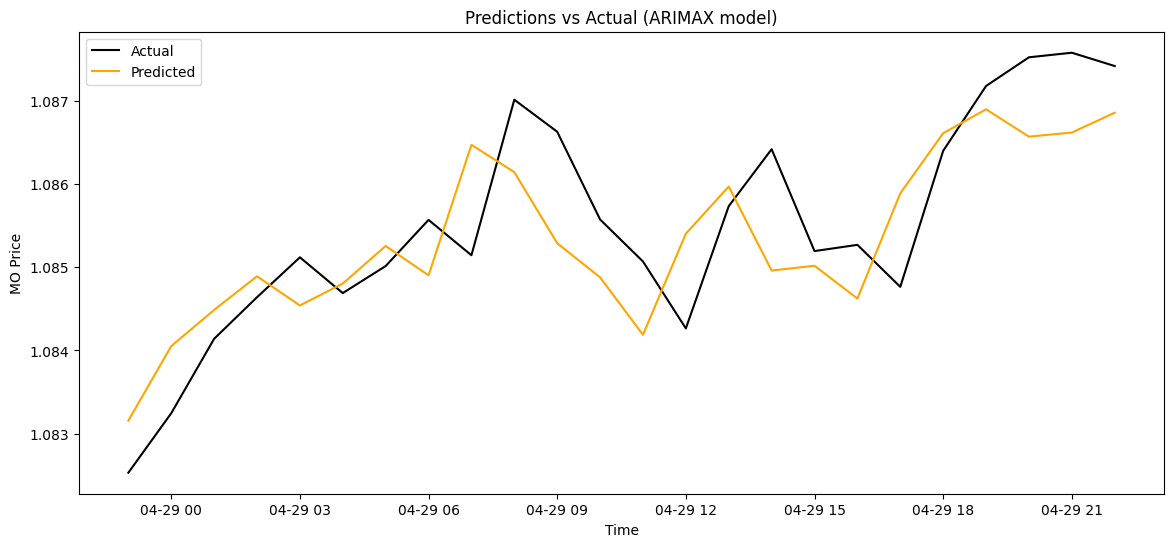

In [50]:

# Plot
plt.figure(figsize=(14,6))
plt.plot(Y_test.index, Y_test.values, label='Actual', color='black')
plt.plot(Y_pred.index, Y_pred, label=f'Predicted', color='orange')
plt.title('Predictions vs Actual (ARIMAX model)')
plt.xlabel('Time')
plt.ylabel('MO Price')
plt.legend()
plt.show()


In [51]:
print("The r2 score is : ", r2_score(Y_test, Y_pred))

The r2 score is :  0.6245471876799993


In [52]:
#evaluating model parameters

Y_train_pred = model_fit.predict(start=X_train.index[0], end=X_train.index[-1], exog=exog_past)
r2_train = r2_score(X_train, Y_train_pred)

print("The rmse of test is  : ",m.sqrt(mean_squared_error(Y_test,Y_pred)))
print("The mae of test is: ",mean_absolute_error(Y_test,Y_pred))
print("The r2 score test is : ",r2_score(Y_test,Y_pred))
print("The r2 score of train is : ",r2_train)
print("The difference in absolute values is : ",abs(r2-r2train))





The rmse of test is  :  0.0007938343887448181
The mae of test is:  0.0006875262772028471
The r2 score test is :  0.6245471876799993
The r2 score of train is :  0.7135699844381425
The difference in absolute values is :  0.1995614864176849


Predicting for 1 week.ARIMA


In [53]:
#Data preparation
l = 24*7*4*2 #cutting the dataframe because my datset to big
n = 24*7

In [55]:
df_red3 = df.iloc[-l:]
display(df_red3)
Y_test = df_red3['MO'].iloc[-n:] #the actual values i wanna predict.The last n
X_train = df_red3['MO'].iloc[:-n]
display(Y_test)
display(X_train)

,BH,BL,BC,BCh,AH,AL,AC,ACh,MO,MO_future
DateTime,,,,,,,,,,
2020-02-12 00:00:00,1.09186,1.09113,1.09126,-0.00058,1.09199,1.09126,1.09138,-0.00058,1.091900,1.065915
2020-02-12 01:00:00,1.09192,1.09124,1.09177,0.00052,1.09205,1.09136,1.09190,0.00053,1.091310,1.068905
2020-02-12 02:00:00,1.09193,1.09140,1.09155,-0.00020,1.09205,1.09153,1.09167,-0.00022,1.091820,1.067895
2020-02-12 03:00:00,1.09173,1.09144,1.09148,-0.00007,1.09186,1.09157,1.09159,-0.00010,1.091620,1.071750
2020-02-12 04:00:00,1.09154,1.09116,1.09116,-0.00032,1.09166,1.09128,1.09128,-0.00033,1.091545,1.072915
...,...,...,...,...,...,...,...,...,...,...
2020-04-29 18:00:00,1.08851,1.08611,1.08713,0.00093,1.08865,1.08640,1.08726,0.00066,1.086400,NaN
2020-04-29 19:00:00,1.08823,1.08659,1.08748,0.00037,1.08837,1.08675,1.08760,0.00035,1.087180,NaN
2020-04-29 20:00:00,1.08788,1.08691,1.08708,-0.00039,1.08810,1.08706,1.08808,0.00050,1.087525,NaN


,MO
DateTime,
2020-04-20 23:00:00,1.086430
2020-04-21 00:00:00,1.086380
2020-04-21 01:00:00,1.085630
2020-04-21 02:00:00,1.084595
2020-04-21 03:00:00,1.083090
...,...
2020-04-29 18:00:00,1.086400
2020-04-29 19:00:00,1.087180
2020-04-29 20:00:00,1.087525


,MO
DateTime,
2020-02-12 00:00:00,1.091900
2020-02-12 01:00:00,1.091310
2020-02-12 02:00:00,1.091820
2020-02-12 03:00:00,1.091620
2020-02-12 04:00:00,1.091545
...,...
2020-04-20 18:00:00,1.086875
2020-04-20 19:00:00,1.086115
2020-04-20 20:00:00,1.085680


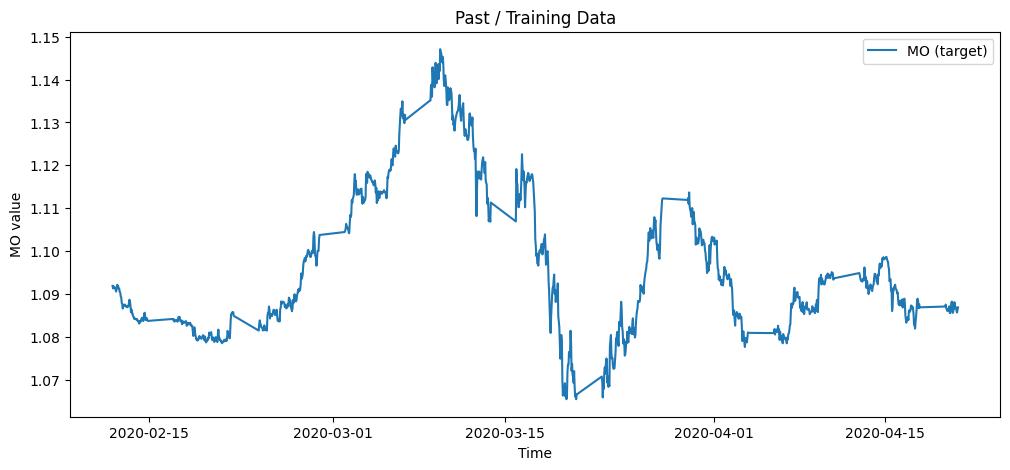

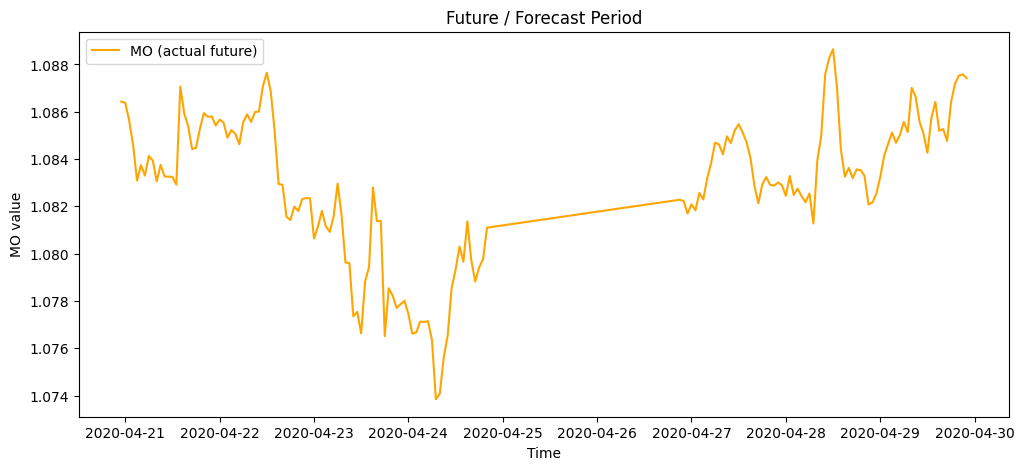

In [56]:
#visualize both trainn and test
plt.figure(figsize=(12,5))
plt.plot(X_train.index, X_train, label='MO (target)')
plt.title('Past / Training Data')
plt.xlabel('Time')
plt.ylabel('MO value')
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(Y_test.index, Y_test, label='MO (actual future)', color='orange')
plt.title('Future / Forecast Period')
plt.xlabel('Time')
plt.ylabel('MO value')
plt.legend()
plt.show()

In [57]:
#Actual ARIMA model
p=1
q=2
model = ARIMA(endog=X_train,order=(p,0,q))
model_fit = model.fit()
Y_pred = model_fit.forecast(steps=n)
Y_pred.index=Y_test.index

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

In [33]:
Y_pred.index=Y_test.index
display(Y_test)
display(Y_pred)

,MO
DateTime,
2020-04-20 23:00:00,1.086430
2020-04-21 00:00:00,1.086380
2020-04-21 01:00:00,1.085630
2020-04-21 02:00:00,1.084595
2020-04-21 03:00:00,1.083090
...,...
2020-04-29 18:00:00,1.086400
2020-04-29 19:00:00,1.087180
2020-04-29 20:00:00,1.087525


,predicted_mean
DateTime,
2020-04-20 23:00:00,1.086913
2020-04-21 00:00:00,1.086949
2020-04-21 01:00:00,1.086990
2020-04-21 02:00:00,1.087031
2020-04-21 03:00:00,1.087072
...,...
2020-04-29 18:00:00,1.091727
2020-04-29 19:00:00,1.091747
2020-04-29 20:00:00,1.091767


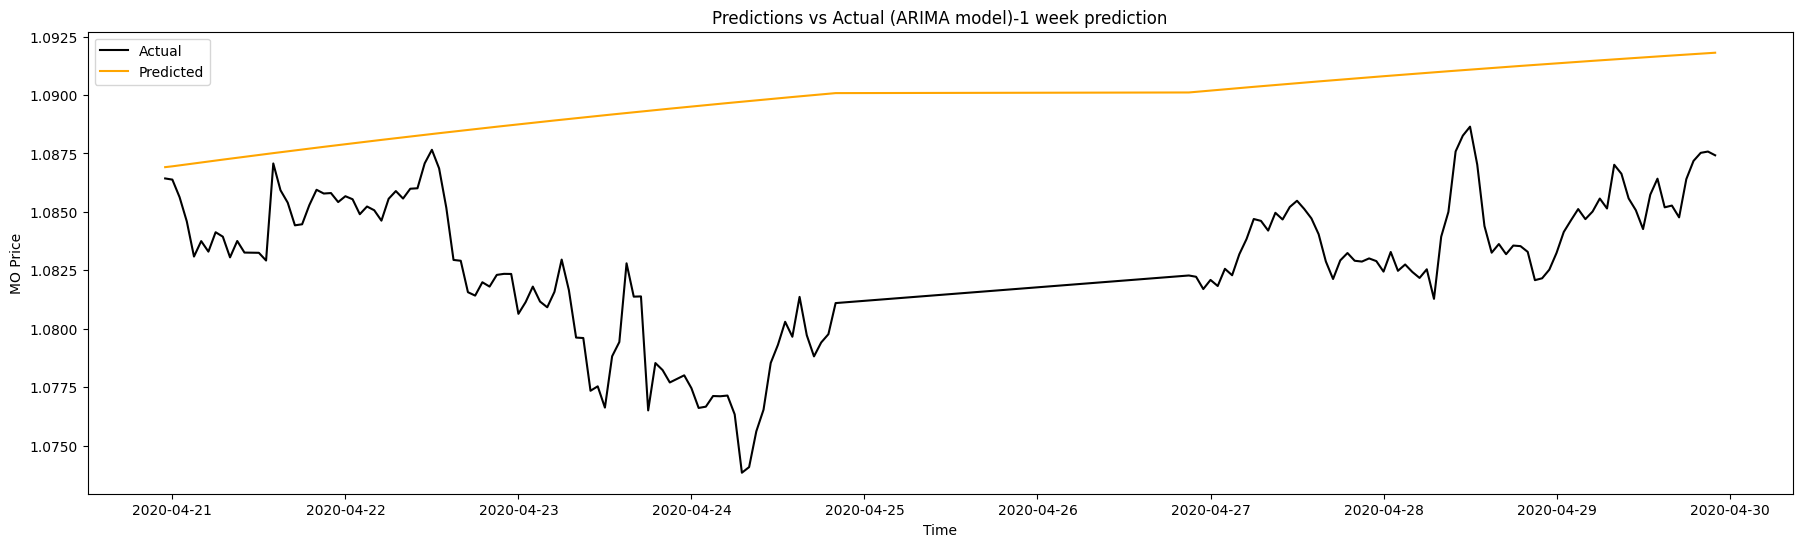

In [58]:

# Plot
plt.figure(figsize=(22,6))
plt.plot(Y_test.index, Y_test.values, label='Actual', color='black')
plt.plot(Y_pred.index, Y_pred, label=f'Predicted', color='orange')
plt.title('Predictions vs Actual (ARIMA model)-1 week prediction')
plt.xlabel('Time')
plt.ylabel('MO Price')
plt.legend()
plt.show()


There is a sudden reverse in direction which ARIMA cannot pick up on no matter if i increase the training window.We will see if adding exogenous features improve this prediction.

In [59]:
#Data preparation
l = 24*7*2 #cutting the dataframe because my datset to big
n = 24*7

In [60]:
df_red4 = df.iloc[-l:]
display(df_red4)
Y_test = df_red4['MO'].iloc[-n:] #the actual values i wanna predict.The last n
X_train = df_red4['MO'].iloc[:-n]
display(Y_test)
display(X_train)

,BH,BL,BC,BCh,AH,AL,AC,ACh,MO,MO_future
DateTime,,,,,,,,,,
2020-04-09 23:00:00,1.09321,1.09168,1.09193,-0.00057,1.09410,1.09239,1.09267,-0.00062,1.092895,NaN
2020-04-10 00:00:00,1.09246,1.09172,1.09207,0.00014,1.09287,1.09214,1.09237,-0.00022,1.092260,NaN
2020-04-10 01:00:00,1.09263,1.09186,1.09261,0.00050,1.09311,1.09223,1.09311,0.00074,1.092240,NaN
2020-04-10 02:00:00,1.09343,1.09239,1.09326,0.00069,1.09386,1.09281,1.09372,0.00064,1.092825,NaN
2020-04-10 03:00:00,1.09430,1.09297,1.09408,0.00093,1.09472,1.09355,1.09450,0.00083,1.093410,NaN
...,...,...,...,...,...,...,...,...,...,...
2020-04-29 18:00:00,1.08851,1.08611,1.08713,0.00093,1.08865,1.08640,1.08726,0.00066,1.086400,NaN
2020-04-29 19:00:00,1.08823,1.08659,1.08748,0.00037,1.08837,1.08675,1.08760,0.00035,1.087180,NaN
2020-04-29 20:00:00,1.08788,1.08691,1.08708,-0.00039,1.08810,1.08706,1.08808,0.00050,1.087525,NaN


,MO
DateTime,
2020-04-20 23:00:00,1.086430
2020-04-21 00:00:00,1.086380
2020-04-21 01:00:00,1.085630
2020-04-21 02:00:00,1.084595
2020-04-21 03:00:00,1.083090
...,...
2020-04-29 18:00:00,1.086400
2020-04-29 19:00:00,1.087180
2020-04-29 20:00:00,1.087525


,MO
DateTime,
2020-04-09 23:00:00,1.092895
2020-04-10 00:00:00,1.092260
2020-04-10 01:00:00,1.092240
2020-04-10 02:00:00,1.092825
2020-04-10 03:00:00,1.093410
...,...
2020-04-20 18:00:00,1.086875
2020-04-20 19:00:00,1.086115
2020-04-20 20:00:00,1.085680


In [63]:
#We will assume that I can get the values of BH and BL due to thier predictability.We can also assume economic statbility wich will cause these values to not fluctuate.
#defining Exogenous fwetures
exog = df_red4[['BC']]
exog_fut=exog.iloc[-n:]
exog_past=exog.iloc[:-n]


In [64]:
display(exog_past)
display(X_train)

,BC
DateTime,
2020-04-09 23:00:00,1.09193
2020-04-10 00:00:00,1.09207
2020-04-10 01:00:00,1.09261
2020-04-10 02:00:00,1.09326
2020-04-10 03:00:00,1.09408
...,...
2020-04-20 18:00:00,1.08606
2020-04-20 19:00:00,1.08563
2020-04-20 20:00:00,1.08620


,MO
DateTime,
2020-04-09 23:00:00,1.092895
2020-04-10 00:00:00,1.092260
2020-04-10 01:00:00,1.092240
2020-04-10 02:00:00,1.092825
2020-04-10 03:00:00,1.093410
...,...
2020-04-20 18:00:00,1.086875
2020-04-20 19:00:00,1.086115
2020-04-20 20:00:00,1.085680


In [65]:
#Actual ARIMAX model
p=0
q=1
model = ARIMA(endog=X_train, exog=exog_past, order=(p,0,q))
model_fit = model.fit()
Y_pred = model_fit.forecast(steps=n, exog=exog_fut)
Y_pred.index=Y_test.index


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

In [66]:
Y_pred.index=Y_test.index
display(Y_test)
display(Y_pred)

,MO
DateTime,
2020-04-20 23:00:00,1.086430
2020-04-21 00:00:00,1.086380
2020-04-21 01:00:00,1.085630
2020-04-21 02:00:00,1.084595
2020-04-21 03:00:00,1.083090
...,...
2020-04-29 18:00:00,1.086400
2020-04-29 19:00:00,1.087180
2020-04-29 20:00:00,1.087525


,predicted_mean
DateTime,
2020-04-20 23:00:00,1.086592
2020-04-21 00:00:00,1.085852
2020-04-21 01:00:00,1.084874
2020-04-21 02:00:00,1.083422
2020-04-21 03:00:00,1.084061
...,...
2020-04-29 18:00:00,1.087391
2020-04-29 19:00:00,1.087730
2020-04-29 20:00:00,1.087342


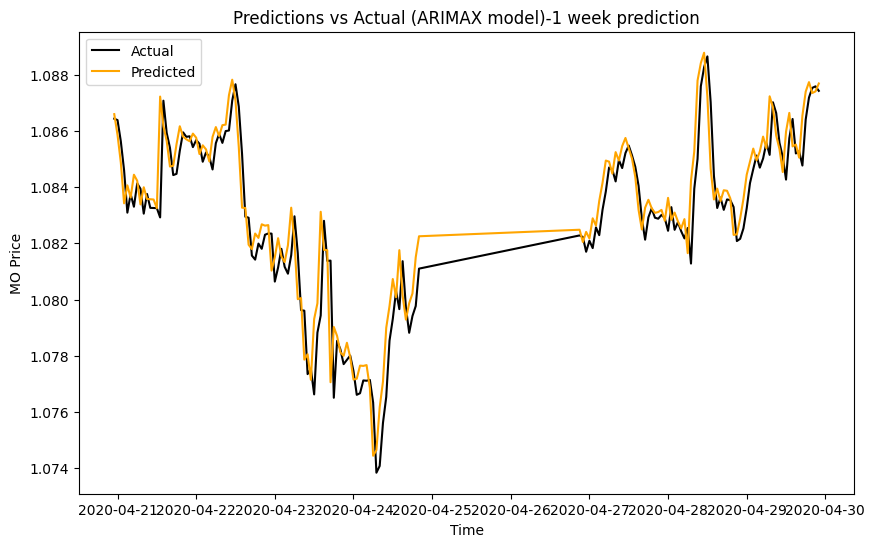

In [67]:

# Plot
plt.figure(figsize=(10,6))
plt.plot(Y_test.index, Y_test.values, label='Actual', color='black')
plt.plot(Y_pred.index, Y_pred, label=f'Predicted', color='orange')
plt.title('Predictions vs Actual (ARIMAX model)-1 week prediction')
plt.xlabel('Time')
plt.ylabel('MO Price')
plt.legend()
plt.show()

In [68]:

#making a prediction on the X_Train and evaluating its values
Y_train_pred = model_fit.predict(start=X_train.index[0], end=X_train.index[-1], exog=exog_past)
r2_train = r2_score(X_train, Y_train_pred)

print("The rmse of test is  : ",m.sqrt(mean_squared_error(Y_test,Y_pred)))
print("The mae of test is: ",mean_absolute_error(Y_test,Y_pred))
print("The r2 score test is : ",r2_score(Y_test,Y_pred))
print("The r2 score of train is : ",r2_train)
print("The difference in absolute values is : ",abs(r2-r2train))





The rmse of test is  :  0.0010985028060989752
The mae of test is:  0.0007953312940126829
The r2 score test is :  0.8698452544915306
The r2 score of train is :  0.9327758798361502
The difference in absolute values is :  0.1995614864176849


Predicting on a month.ARIMA


In [69]:
#Data preparation
l = 24*7*4*6#cutting the dataframe because my datset to big
n = 24*7*4

In [70]:
df_red4 = df.iloc[-l:]
Y_test = df_red4['MO'].iloc[-n:] #the actual values i wanna predict.The last n
X_train = df_red4['MO'].iloc[:-n]
display(Y_test)
display(X_train)

,MO
DateTime,
2020-03-22 23:00:00,1.065915
2020-03-23 00:00:00,1.068905
2020-03-23 01:00:00,1.067895
2020-03-23 02:00:00,1.071750
2020-03-23 03:00:00,1.072915
...,...
2020-04-29 18:00:00,1.086400
2020-04-29 19:00:00,1.087180
2020-04-29 20:00:00,1.087525


,MO
DateTime,
2019-09-03 23:00:00,1.097115
2019-09-04 00:00:00,1.097265
2019-09-04 01:00:00,1.097445
2019-09-04 02:00:00,1.097405
2019-09-04 03:00:00,1.097495
...,...
2020-03-20 18:00:00,1.066675
2020-03-20 19:00:00,1.065490
2020-03-20 20:00:00,1.066595


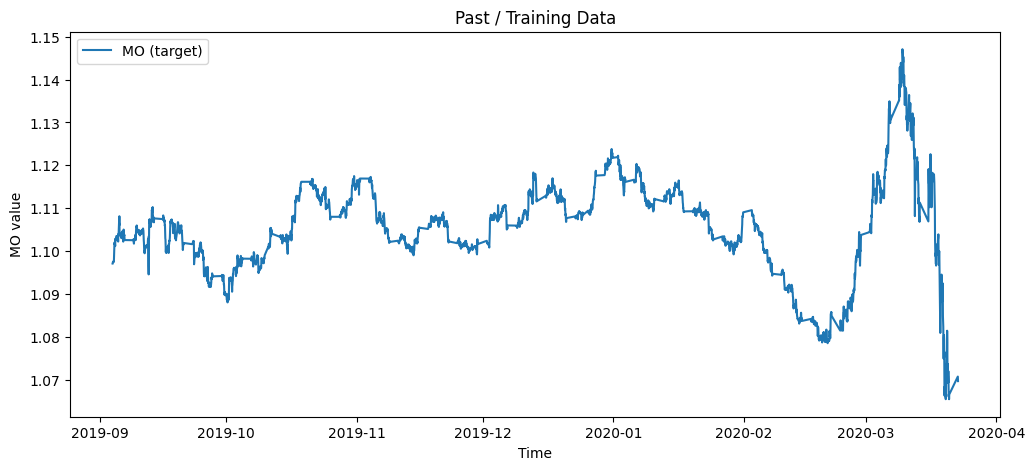

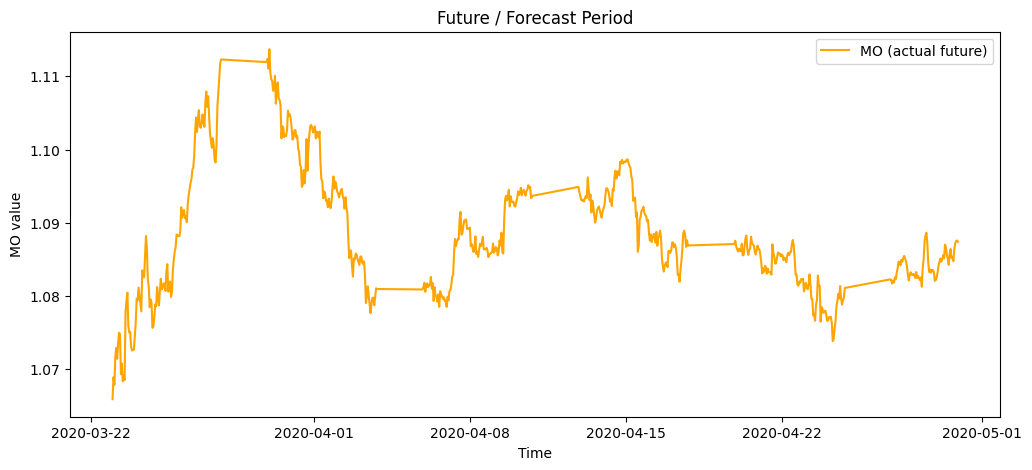

In [71]:
#visualize both trainn and test
plt.figure(figsize=(12,5))
plt.plot(X_train.index, X_train, label='MO (target)')
plt.title('Past / Training Data')
plt.xlabel('Time')
plt.ylabel('MO value')
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(Y_test.index, Y_test, label='MO (actual future)', color='orange')
plt.title('Future / Forecast Period')
plt.xlabel('Time')
plt.ylabel('MO value')
plt.legend()
plt.show()

In [72]:
p=1
q=2
model = ARIMA(endog=X_train,order=(p,0,q))
model_fit = model.fit()
Y_pred = model_fit.forecast(steps=n)
Y_pred.index=Y_test.index

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

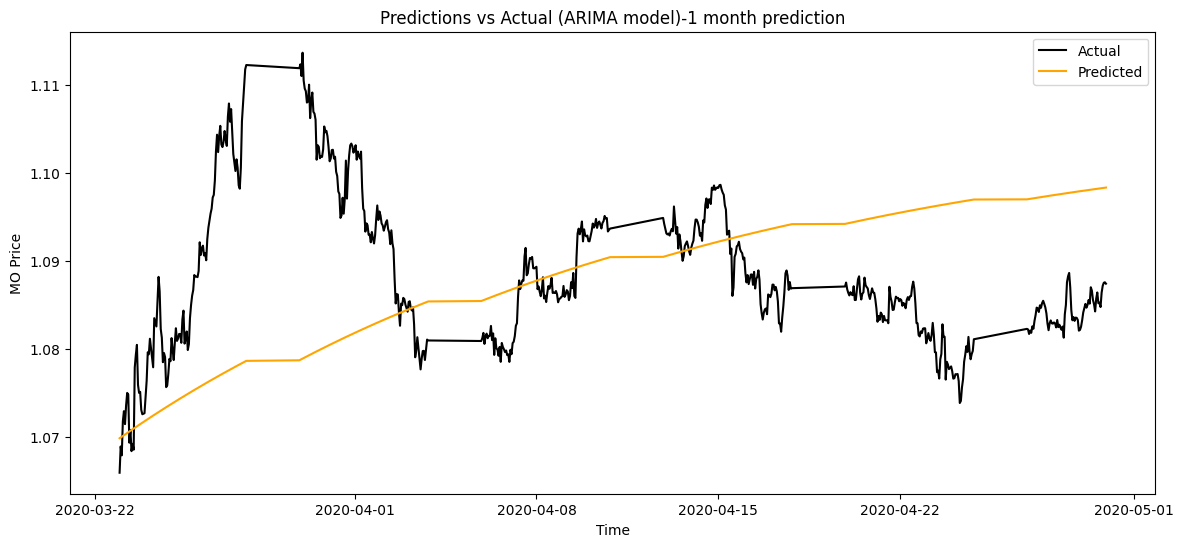

In [73]:

# Plot
plt.figure(figsize=(14,6))
plt.plot(Y_test.index, Y_test.values, label='Actual', color='black')
plt.plot(Y_pred.index, Y_pred, label=f'Predicted', color='orange')
plt.title('Predictions vs Actual (ARIMA model)-1 month prediction')
plt.xlabel('Time')
plt.ylabel('MO Price')
plt.legend()1
plt.show()


CASO AR

In [74]:
#fix at 6 months-> thn predict at 1 month
#fix at 1 month, predict at 1 day
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [75]:
# Ensure the index is a DatetimeIndex and interpolate any missing values
# The 'DateTime' column is already the index, and its type is DatetimeIndex.
# We need to enforce a '10h' frequency.

# Use .asfreq() to resample the DataFrame to a fixed '10h' frequency.
# This will ensure the index has the desired frequency and fill any gaps with NaN.
df_t = df.asfreq('10h')

# Interpolate missing values in 'MO' that might have been introduced by asfreq()
# or that existed previously.
df_t["MO"] = df_t["MO"].interpolate()


In [76]:
#the price series must be stationary, yse ADF statistic
result = adfuller(df_t["MO"])
print(f"ADF statistic = {result[0]:.3f}, p-value = {result[1]:.3f}")
#si ambos mayor de 0.05, el serie no es estacionaria.
#take first diff to remove trend y achieve stationary
#df_diff = df_t["MO"].diff().dropna()                                             #buang differentiate

ADF statistic = -1.636, p-value = 0.464


In [77]:
last_3m_start = df_t.index.max() - pd.DateOffset(months=3)
df_3m = df_t[df_t.index >= last_3m_start]

result = adfuller(df_3m["MO"])
print(f"ADF statistic = {result[0]:.3f}, p-value = {result[1]:.3f}")
if result[1] < 0.05:
    print("Series is likely stationary")
else:
    print("Series is likely non-stationary")

ADF statistic = -3.010, p-value = 0.034
Series is likely stationary


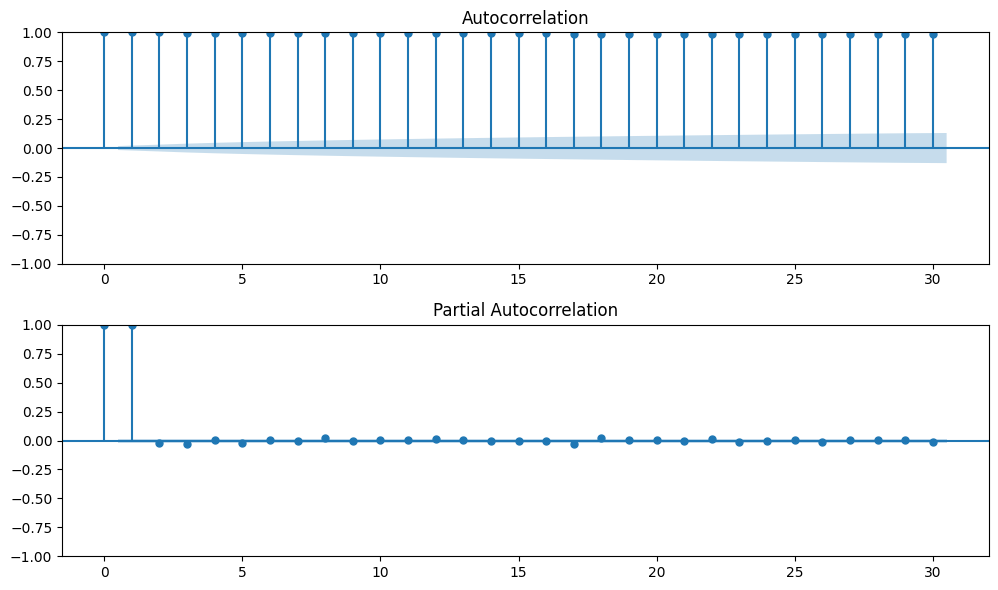

In [78]:
#plot ACF y PACF to identify appropiate lag order p
fig, ax = plt.subplots(2,1, figsize=(10,6))
plot_acf(df_t["MO"], lags=30, ax=ax[0])
plot_pacf(df_t["MO"], lags=30, ax=ax[1])
plt.tight_layout()
plt.show()

                            AutoReg Model Results                             
Dep. Variable:                     MO   No. Observations:                  720
Model:                     AutoReg(2)   Log Likelihood                3328.277
Method:               Conditional MLE   S.D. of innovations              0.002
Date:                Tue, 09 Dec 2025   AIC                          -6648.554
Time:                        16:54:48   BIC                          -6630.248
Sample:                    05-26-2019   HQIC                         -6641.486
                         - 03-20-2020                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0098      0.008      1.236      0.216      -0.006       0.025
MO.L1          0.9167      0.037     24.468      0.000       0.843       0.990
MO.L2          0.0744      0.038      1.977      0.0

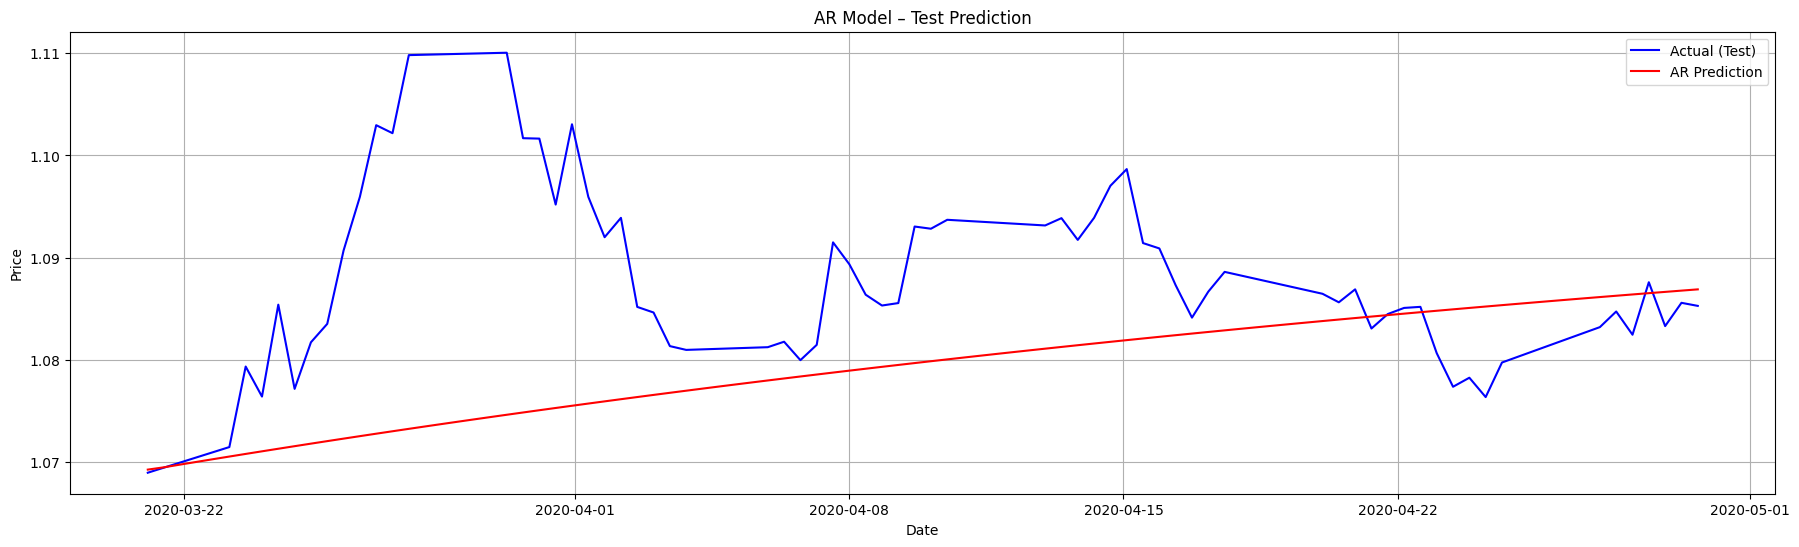

In [79]:
un_mes = 24*30        # 1 month
dos_dias = 24 *4     # 2 days
p = 2 # AR lag order

#train test split
train = df_t['MO'].iloc[-(un_mes + dos_dias) : - dos_dias]
test   = df_t['MO'].iloc[-dos_dias:]

# Fit AR model
model = AutoReg(train, lags=p, old_names=False)
model_fit = model.fit()
print(model_fit.summary())

# Predict on test
pred_ar_test = model_fit.predict(start=test.index[0], end=test.index[-1])
# If the model is not trained on differenced data, pred_ar_test are the direct predictions
forecast_test = pred_ar_test # No cumsum needed if model is on original series
forecast_test.index = test.index

rmse_AR = np.sqrt(mean_squared_error(test, pred_ar_test))
mae = mean_absolute_error(test, pred_ar_test)
print("RMSE:", rmse_AR, "MAE:", mae)


# Comparison df
comparison = pd.DataFrame({
    "Actual": df_t["MO"].loc[test.index],
    "Predicted_AR": forecast_test
})

# Plot
fig, ax = plt.subplots(figsize=(22,6))

ax.plot(comparison.index, comparison["Actual"], label="Actual (Test)", color="blue")
ax.plot(comparison.index, comparison["Predicted_AR"], label="AR Prediction", color="red")
#ax.plot(forecast_future.index, forecast_future, label="AR 7-day Forecast", linestyle="--")
#ax.fill_between(forecast_future.index, ci_low, ci_high, color="gray", alpha=0.3, label="Confidence Interval")

ax.set_title("AR Model – Test Prediction")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
ax.grid(True)
plt.show()

In [ ]:
print(rmse_AR)
print(r2_score(test,pred_ar_test))